In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [6]:
# Define State
class QuadraticState(TypedDict):
    a: int
    b: int
    c: int
    
    equation: str
    descriment: float
    result: str

In [7]:
def show_equation(state: QuadraticState):
    equation = f"{state["a"]} x 2*{state["b"]} x {state['c']}"
    
    return {'equation': equation}

def calculate_descriminent(state: QuadraticState):
    descriment = state['b']**2 - (4*state['a']*state['c'])
    
    return {'descriment': descriment}

def real_root(state: QuadraticState):
    root1 = (-state['b'] + state['descriment']**0.5)/(2*state['a'])
    root2 = (-state['b'] - state['descriment']**0.5)/(2*state['a'])
    
    result = f"The roots are {root1} and {root2}"
    
    return {"result": result}

def repeated_root(state: QuadraticState):
    root = (-state['b'])/(2*state['a'])
    
    result = f"Only repeating root is {root}"
    
    return {"result": result}

def not_real_root(state: QuadraticState):
    result = f"No real roots are present"
    
    return {"result": result}


def check_codition(state: QuadraticState) -> Literal["real_root", "not_real_root", "repeated_root"]:
    if state['descriment'] > 0:
        return "real_root"
    elif state['descriment'] == 0:
        return "repeated_root"
    else:
        return "not_real_root"

In [9]:
graph = StateGraph(QuadraticState)

# Add Node
graph.add_node("show_equation", show_equation)
graph.add_node("calculate_descriminent", calculate_descriminent)
graph.add_node("real_root", real_root)
graph.add_node("not_real_root", not_real_root)
graph.add_node("repeated_root", repeated_root)

# Define Edges
graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "calculate_descriminent")

graph.add_conditional_edges("calculate_descriminent", check_codition)

graph.add_edge("real_root", END)
graph.add_edge("repeated_root", END)
graph.add_edge("not_real_root", END)


workflow = graph.compile()


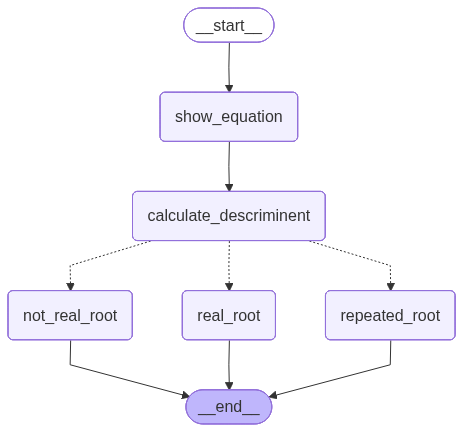

In [10]:
workflow

In [11]:
initial_state = {
    'a': 2, 
    'b': 4,
    'c': 2
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2 x 2*4 x 2',
 'descriment': 0,
 'result': 'Only repeating root is -1.0'}